In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
df_raw = pd.read_csv("retail_sales_messy.csv")

In [5]:
df = df_raw.copy()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OrderID       228 non-null    int64  
 1   CustomerName  228 non-null    object 
 2   Product       228 non-null    object 
 3   Category      228 non-null    object 
 4   Price         218 non-null    object 
 5   Quantity      228 non-null    int64  
 6   OrderDate     228 non-null    object 
 7   City          228 non-null    object 
 8   Rating        217 non-null    float64
dtypes: float64(1), int64(2), object(6)
memory usage: 16.2+ KB


In [7]:
df.describe()

,OrderID,Quantity,Rating
count,228.000000,228.000000,217.000000
mean,1108.714912,2.877193,3.681567
std,63.188009,1.493837,0.682677
min,1000.000000,-4.000000,2.500000
25%,1054.750000,2.000000,3.100000
50%,1106.500000,3.000000,3.700000
75%,1163.250000,4.000000,4.100000
max,1219.000000,5.000000,5.000000


In [8]:
df.isnull().sum()

OrderID          0
CustomerName     0
Product          0
Category         0
Price           10
Quantity         0
OrderDate        0
City             0
Rating          11
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(8)

In [10]:
df

,OrderID,CustomerName,Product,Category,Price,Quantity,OrderDate,City,Rating
0,1099,Sanjay Verma,Jeans,Clothing,2426.56,4,2024-05-15,Bengaluru,3.9
1,1046,Pooja Gupta,Sofa,Home,44465.05,4,02/01/2024,Hyderabad,3.8
2,1105,Divya Sharma,T-Shirt,Clothing,1102.71,2,05/06/2024,pune,2.7
3,1022,Aman Das,Sofa,Home,41616.38,1,15-03-2024,New Delhi,3.5
4,1078,Isha Sharma,Sneakers,Footwear,₹4252.74,3,16/03/2024,pune,3.1
...,...,...,...,...,...,...,...,...,...
223,1211,Anjali Patel,Sofa,Home,32623.61,1,15-02-2024,mumbai,4.4
224,1067,Omar Gupta,Sofa,Home,34498.92,4,2024-12-15,MUMBAI,4.7
225,1025,Vikram Iyer,Sofa,Home,15942.88,1,2024-05-04,Pune,3.3
226,1196,Omar Singh,Sneakers,Footwear,5055.38,5,10/01/2024,CHENNAI,4.3


In [11]:
df["CustomerName"] = df["CustomerName"].str.strip().str.lower()


In [12]:
df["Product"] = df["Product"].str.strip().str.lower()

In [12]:
df["Category"] = df["Category"].str.strip().str.lower()

In [13]:
df["Price"] = df["Price"].apply(str).str.replace("₹","").apply(float)

In [14]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"],format="mixed" , errors="coerce")

In [15]:
df["City"] = df["City"].str.strip().str.lower()

In [16]:
df["Rating"] = df["Rating"].fillna(0)

In [17]:
df["Rating"].isnull().sum()

np.int64(0)

In [18]:
df["Price"].isnull().sum()

np.int64(10)

In [19]:
df = df.dropna(subset=["Price"])

In [20]:
df["Price"].isnull().sum()

np.int64(0)

In [21]:
df.isnull().sum()

OrderID         0
CustomerName    0
Product         0
Category        0
Price           0
Quantity        0
OrderDate       0
City            0
Rating          0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(7)

In [23]:
df = df.drop_duplicates().reset_index(drop=True)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   OrderID       211 non-null    int64         
 1   CustomerName  211 non-null    object        
 2   Product       211 non-null    object        
 3   Category      211 non-null    object        
 4   Price         211 non-null    float64       
 5   Quantity      211 non-null    int64         
 6   OrderDate     211 non-null    datetime64[ns]
 7   City          211 non-null    object        
 8   Rating        211 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 15.0+ KB


In [25]:
df.describe()

,OrderID,Price,Quantity,OrderDate,Rating
count,211.000000,211.000000,211.000000,211,211.000000
mean,1109.957346,16120.607441,2.900474,2024-06-29 23:19:03.127962112,3.503318
min,1001.000000,324.390000,-4.000000,2024-01-01 00:00:00,0.000000
25%,1055.500000,1116.300000,2.000000,2024-04-08 00:00:00,3.100000
50%,1110.000000,2797.240000,3.000000,2024-07-08 00:00:00,3.700000
75%,1165.500000,21583.060000,4.000000,2024-09-14 12:00:00,4.100000
max,1219.000000,204571.360000,5.000000,2024-12-28 00:00:00,5.000000
std,63.767980,28310.479293,1.510140,NaN,1.057823


In [26]:
df["Revenue"] = df["Price"]*df["Quantity"]

In [27]:
total_revenue_per_category = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

In [28]:
total_revenue_per_category

Category
electronics    6117794.39
home           2826159.01
footwear        359465.07
clothing        272954.88
Name: Revenue, dtype: float64

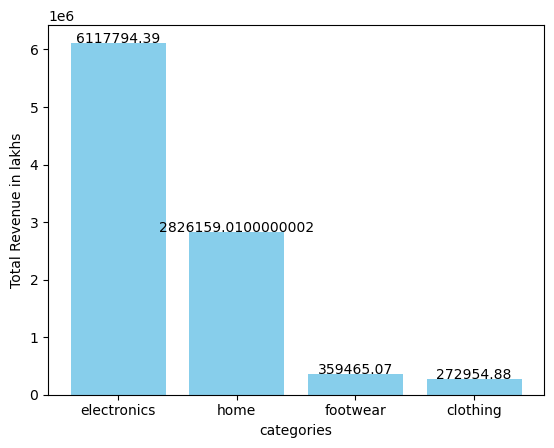

In [29]:
plt.bar(total_revenue_per_category.index , total_revenue_per_category.values , color="skyblue")
plt.xlabel("categories")
plt.ylabel("Total Revenue in lakhs")

x = np.array(total_revenue_per_category.values)

for i in range(len(x)):
    plt.text(i,x[i],str(x[i]),ha="center")

plt.show()



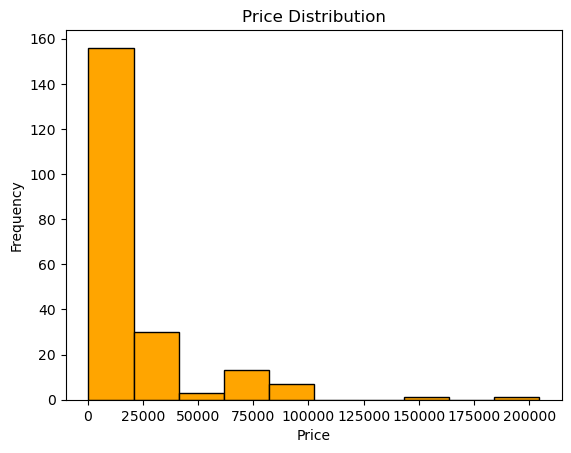

In [30]:
plt.hist(df["Price"] , bins=10 , edgecolor="black" , color="orange")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.show()

In [32]:
total_revenue_per_category

Category
electronics    6117794.39
home           2826159.01
footwear        359465.07
clothing        272954.88
Name: Revenue, dtype: float64

In [33]:
cats = [i for i in total_revenue_per_category.index]
cats

['electronics', 'home', 'footwear', 'clothing']

In [34]:
sales = [int(i) for i in total_revenue_per_category]
sales

[6117794, 2826159, 359465, 272954]

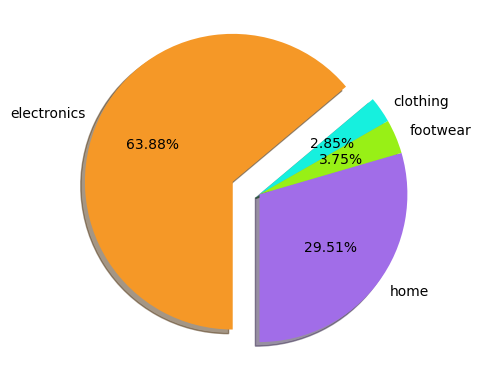

In [35]:
colors = ["#F59827","#A16DE8","#98F016","#16F0DE"]
explode = [0.2,0,0,0]
plt.pie(sales,labels=cats,colors=colors,explode=explode,shadow=True,autopct="%1.2f%%",startangle=40)
plt.show()


In [36]:
df

,OrderID,CustomerName,Product,Category,Price,Quantity,OrderDate,City,Rating,Revenue
0,1099,Sanjay Verma,jeans,clothing,2426.56,4,2024-05-15,bengaluru,3.9,9706.24
1,1046,Pooja Gupta,sofa,home,44465.05,4,2024-02-01,hyderabad,3.8,177860.20
2,1105,Divya Sharma,t-shirt,clothing,1102.71,2,2024-05-06,pune,2.7,2205.42
3,1022,Aman Das,sofa,home,41616.38,1,2024-03-15,new delhi,3.5,41616.38
4,1078,Isha Sharma,sneakers,footwear,4252.74,3,2024-03-16,pune,3.1,12758.22
...,...,...,...,...,...,...,...,...,...,...
206,1211,Anjali Patel,sofa,home,32623.61,1,2024-02-15,mumbai,4.4,32623.61
207,1067,Omar Gupta,sofa,home,34498.92,4,2024-12-15,mumbai,4.7,137995.68
208,1025,Vikram Iyer,sofa,home,15942.88,1,2024-05-04,pune,3.3,15942.88
209,1196,Omar Singh,sneakers,footwear,5055.38,5,2024-10-01,chennai,4.3,25276.90


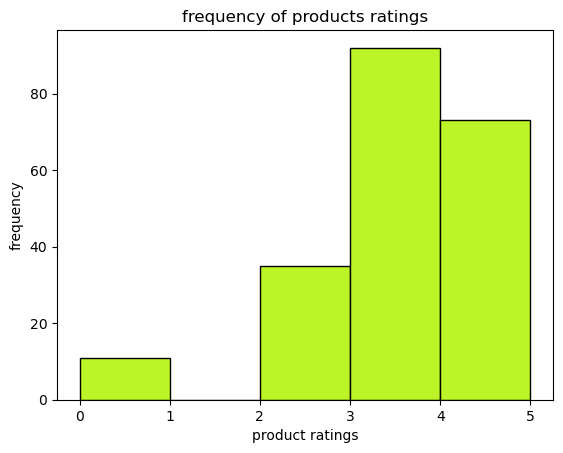

In [48]:
plt.hist(df["Rating"],bins=5, edgecolor="black" , color="#BBF527")
plt.xlabel("product ratings")
plt.ylabel("frequency")
plt.title("frequency of products ratings")
plt.show()